In [34]:
import os
import glob
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import ChromBERT utilities
import css_utility as crb

In [35]:
files = sorted(glob.glob("../processed/ltr_per_celltype/E*_ltr_pm1kb.csv"))
print("n_files:", len(files))  # should be 127

df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(df_all.shape)

n_files: 127
(85363427, 11)


In [36]:
cell_ids = sorted({os.path.basename(f).split("_")[0] for f in files})
print(cell_ids[:10])
print(cell_ids[-10:])

['E001', 'E002', 'E003', 'E004', 'E005', 'E006', 'E007', 'E008', 'E009', 'E010']
['E120', 'E121', 'E122', 'E123', 'E124', 'E125', 'E126', 'E127', 'E128', 'E129']


In [46]:
df_all["eid_num"] = df_all["cell_id"].str.replace("E", "", regex=False).astype(int)
## Cancer samples are E114 to E129 (inclusive)
df_all["is_cancer"] = df_all["eid_num"].between(114, 129)

In [ ]:
df_normal = df_all[~df_all["is_cancer"]].copy()
df_cancer = df_all[df_all["is_cancer"]].copy()

In [ ]:
print(df_normal.shape)
print(df_cancer.shape)

(74650203, 13)
(10713224, 13)


In [ ]:
df_normal["O_ratio"] = df_normal["state_seq_full_slice"].str.count("O") / df_normal["n_bins"]

<Axes: >

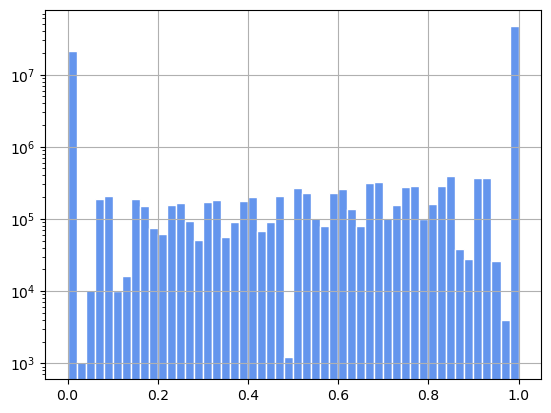

In [ ]:
# df_normal["O_ratio"].hist(bins=50)
df_normal["O_ratio"].hist(bins=50, log=True, color="cornflowerblue", edgecolor="white")

<Axes: >

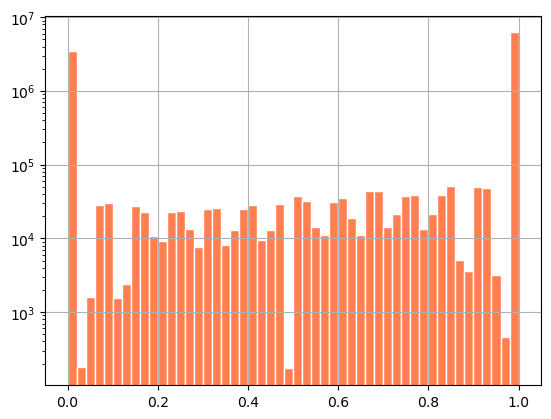

In [ ]:
df_cancer["O_ratio"] = df_cancer["state_seq_full_slice"].str.count("O") / df_cancer["n_bins"]
df_cancer["O_ratio"].hist(bins=50, log=True, color="coral", edgecolor="white")

In [16]:
print((df_normal["O_ratio"] == 1).mean())
print((df_normal["O_ratio"] == 0).mean())

0.6202536247624135
0.28275435500155305


In [38]:
print((df_cancer["O_ratio"] == 1).mean())
print((df_cancer["O_ratio"] == 0).mean())

0.578746883291155
0.3275929822805908


### Fully engaged case (No O state)

In [39]:
from collections import Counter

def state_counts(seq):
    return Counter(seq)

df_normal_engaged = df_normal[df_normal["O_ratio"] == 0]
df_cancer_engaged = df_cancer[df_cancer["O_ratio"] == 0]

In [21]:
df_normal_engaged

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,cell_id,source_bed,eid_num,is_cancer,O_ratio,n_transitions
174,chr1,634542,636856,LTR39,3635.0,-,2314,NNNNNNNNNMMMM,13,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0,1
175,chr1,635155,637458,LTR39,3635.0,-,2303,NNNNNNMMMMMMM,13,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0,1
176,chr1,635578,637722,LTR39,3635.0,-,2144,NNNNMMMMMMMM,12,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0,1
177,chr1,637233,639361,LTR33,473.0,+,2128,MMMNNNNNMMM,11,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0,2
178,chr1,639608,641898,MLT1H,586.0,-,2290,MMMMMMMMMMMM,12,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74650198,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12,E113,E113_15_coreMarks_hg38lift_mnemonics.bed,113,False,0.0,0
74650199,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13,E113,E113_15_coreMarks_hg38lift_mnemonics.bed,113,False,0.0,0
74650200,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14,E113,E113_15_coreMarks_hg38lift_mnemonics.bed,113,False,0.0,0
74650201,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12,E113,E113_15_coreMarks_hg38lift_mnemonics.bed,113,False,0.0,0


In [40]:
df_cancer_engaged

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,cell_id,source_bed,eid_num,is_cancer,O_ratio
74650377,chr1,634542,636856,LTR39,3635.0,-,2314,NNNNNNNNNNNNN,13,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
74650378,chr1,635155,637458,LTR39,3635.0,-,2303,NNNNNNNNNNNNN,13,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
74650379,chr1,635578,637722,LTR39,3635.0,-,2144,NNNNNNNNNNNN,12,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
74650380,chr1,637233,639361,LTR33,473.0,+,2128,NNNNNNNNNNN,11,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
74650381,chr1,639608,641898,MLT1H,586.0,-,2290,NNNNNNNNNNNN,12,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85363422,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True,0.0
85363423,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True,0.0
85363424,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True,0.0
85363425,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True,0.0


In [41]:
from collections import Counter

all_seq_normal_engaged = "".join(df_normal_engaged["state_seq_full_slice"].dropna())
all_seq_cancer_engaged = "".join(df_cancer_engaged["state_seq_full_slice"].dropna())

state_counts_normal_engaged = Counter(all_seq_normal_engaged)
state_counts_cancer_engaged = Counter(all_seq_cancer_engaged)

In [42]:
total_normal_engaged = sum(state_counts_normal_engaged.values())
total_cancer_engaged = sum(state_counts_cancer_engaged.values())

state_freq_normal_engaged = {k: v / total_normal_engaged for k, v in state_counts_normal_engaged.items()}
state_freq_cancer_engaged = {k: v / total_cancer_engaged for k, v in state_counts_cancer_engaged.items()}

In [43]:
import matplotlib.pyplot as plt

# A~O order
state_order = list("ABCDEFGHIJKLMNO")

# fill 0 for missing states
state_freq_ordered_normal_engaged = {k: state_freq_normal_engaged.get(k, 0) for k in state_order}
state_freq_ordered_cancer_engaged = {k: state_freq_cancer_engaged.get(k, 0) for k in state_order}

# color mapping based on ChromBERT's state_col_dict_num
colors = [crb.state_col_dict_num[k] for k in state_order]

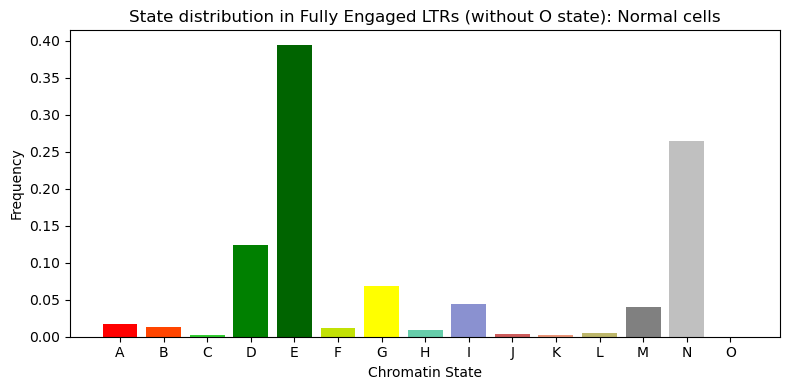

In [44]:
# plot normal
plt.figure(figsize=(8,4))
plt.bar(state_order, state_freq_ordered_normal_engaged.values(), color=colors)

plt.xlabel("Chromatin State")
plt.ylabel("Frequency")
plt.title("State distribution in Fully Engaged LTRs (without O state): Normal cells")

plt.tight_layout()
plt.show()

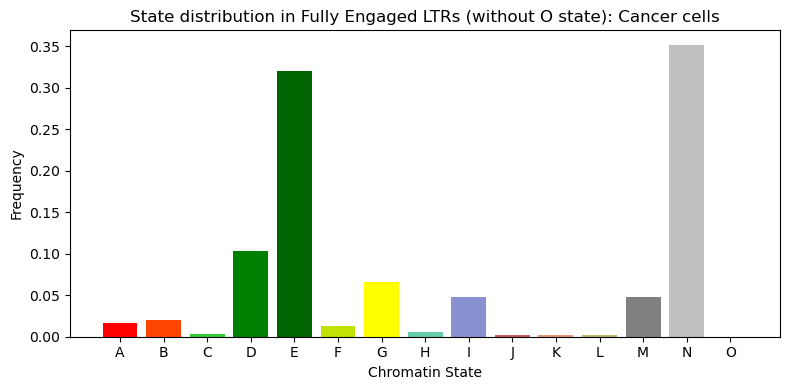

In [45]:
# plot cancer
plt.figure(figsize=(8,4))
plt.bar(state_order, state_freq_ordered_cancer_engaged.values(), color=colors)

plt.xlabel("Chromatin State")
plt.ylabel("Frequency")
plt.title("State distribution in Fully Engaged LTRs (without O state): Cancer cells")

plt.tight_layout()
plt.show()

In [12]:
def count_transitions(seq):
    return sum(1 for i in range(len(seq)-1) if seq[i] != seq[i+1])

df_normal["n_transitions"] = df_normal["state_seq_full_slice"].apply(count_transitions)

<Axes: >

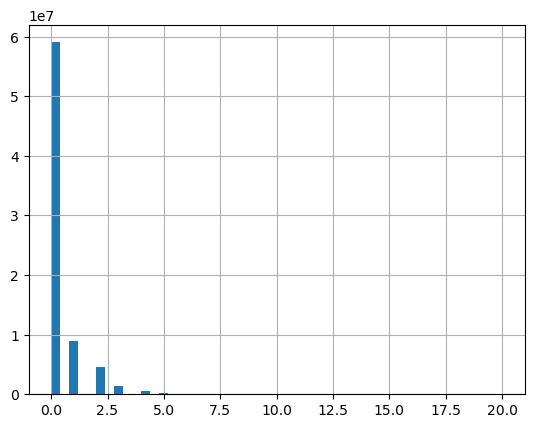

In [13]:
df_normal["n_transitions"].hist(bins=50)

Text(0, 0.5, 'n_transitions')

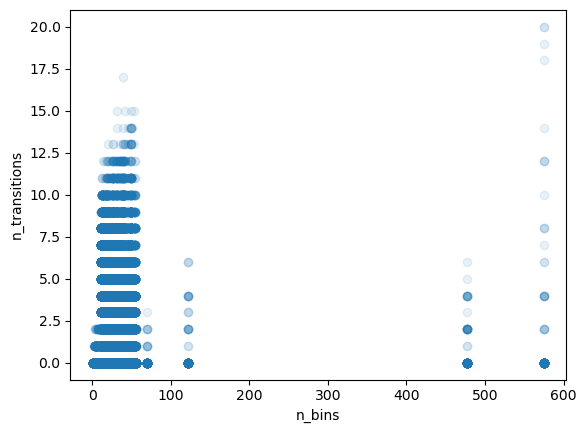

In [14]:
import matplotlib.pyplot as plt

plt.scatter(df_normal["n_bins"], df_normal["n_transitions"], alpha=0.1)
plt.xlabel("n_bins")
plt.ylabel("n_transitions")